# EXPERIMENT 1 — STABLE MODEL DEVELOPMENT 

## **Objective**

Build a strong and interpretable Logistic Regression baseline using the cleaned and engineered Lending Club dataset. This model will establish the benchmark against which more complex models (Random Forest, XGBoost, LightGBM) will be compared.

Goal: Test how well a simple linear model performs after careful preprocessing and feature engineering, before moving to non-linear models.

In [1]:
import psutil

mem = psutil.virtual_memory()
print(f"Total RAM: {mem.total / 1e9:.2f} GB")
print(f"Available: {mem.available / 1e9:.2f} GB")
print(f"Used: {mem.percent}%")

Total RAM: 8.22 GB
Available: 2.54 GB
Used: 69.0%


## Phase 1 — Baseline Model(Logistic Regression)

In [2]:
import numpy as np
import pandas as pd
import os

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Features
X_train_path = os.path.join(project_root, 'src','data', 'processed','parquet_chunks','X_train_fe.parquet')

X_val_path = os.path.join(project_root,'src','data', 'processed','parquet_chunks', 'X_val_fe.parquet')

X_test_path = os.path.join(project_root, 'src','data', 'processed','parquet_chunks','X_test_fe.parquet')

# target
y_train_path = os.path.join(project_root,'src','data','processed','parquet_chunks','y_train.parquet')

y_val_path = os.path.join(project_root,'src','data','processed','parquet_chunks','y_val.parquet')

y_test_path = os.path.join(project_root,'src','data','processed','parquet_chunks','y_test.parquet')

In [4]:
# =========================================================
# Load Processed Data
# =========================================================


X_train = pd.read_parquet(X_train_path)
X_val = pd.read_parquet(X_val_path)
X_test = pd.read_parquet(X_test_path)

y_train = pd.read_parquet(y_train_path).squeeze()
y_val = pd.read_parquet(y_val_path).squeeze()
y_test = pd.read_parquet(y_test_path).squeeze()

In [5]:
X_train.shape

(623267, 150)

### **Baseline Dataset**

In [6]:
tradeline_data_keep_nan = [
    'open_acc_6m',
    'open_rv_12m', 
    'open_rv_24m',
    'open_il_12m', 
    'open_il_24m', 
    'open_act_il',
    'total_bal_il', 
    'inq_fi', 
    'total_cu_tl',
    'inq_last_12m',
    'max_bal_bc', 
    'all_util',
    'mths_since_rcnt_il',
    'il_util'
]

In [7]:
sentinel_cols = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_last_major_derog',
    'mths_since_recent_revol_delinq',
]

###  Dropped Sentinel Columns (LR only)

**Columns dropped:**
- `mths_since_last_delinq`
- `mths_since_last_record`
- `mths_since_recent_bc_dlq`
- `mths_since_last_major_derog`
- `mths_since_recent_revol_delinq`

**Reason:** These columns use 999 to represent "event never occurred", mixed with genuine numeric values for borrowers who experienced the event. Missingness ranged from 51–84%, making the sentinel value the dominant category. Since Logistic Regression models each feature with a single linear coefficient, treating 999 as a numeric value can misrepresent the relationship between the feature and the target, even after scaling.

**Decision:** Dropped for Logistic Regression only. Retained for tree-based models (Random Forest, XGBoost, LightGBM), which can naturally split on the sentinel value and learn separate decision boundaries.

In [8]:
cols_to_drop = tradeline_data_keep_nan + sentinel_cols + ['issue_year'] 

X_train_lr = X_train.drop(columns = cols_to_drop)

X_val_lr = X_val.drop(columns = cols_to_drop)

X_test_lr = X_test.drop(columns = cols_to_drop)

In [9]:
print("Train shape:", X_train_lr.shape)
print("Validation shape:", X_val_lr.shape)
print("Test shape:", X_test_lr.shape)

print("\nRemaining missing values")
print("Train:", X_train_lr.isna().sum().sum())
print("Validation:", X_val_lr.isna().sum().sum())
print("Test:", X_test_lr.isna().sum().sum())

Train shape: (623267, 130)
Validation shape: (223330, 130)
Test shape: (180970, 130)

Remaining missing values
Train: 0
Validation: 0
Test: 0


In [10]:
# =========================================================
# Check Class Imbalance
# =========================================================

y_train.value_counts(normalize = True)

target
0    0.813645
1    0.186355
Name: proportion, dtype: float64

In [11]:
# default rate
default_rate = y_train.mean() * 100

print(f" Default Rate : {default_rate:.2f}%")

 Default Rate : 18.64%


### **Scale Numerical Features**

In [12]:
# Find the actual  OHE expanded column names

ohe_expanded = [
    c for c in X_train_lr.columns
    if c.startswith('purpose_') 
    or c.startswith('addr_state_')
    or c.startswith('home_ownership_')]

#print(ohe_expanded)
print(len(ohe_expanded))

63


In [13]:
# ['delinq_amnt'] -> zero variance from graphs(wisorization, log1p)
# Find the problematic column
col = 'delinq_amnt'

if col not in X_train_lr.columns:
    print(f"Column '{col}' not found.")
else:
    s = X_train_lr[col]
    print(f"Column: {col}")
    print(f"  rows:    {len(s)}")
    print(f"  non-null:{s.count()}")
    print(f"  nulls:   {s.isnull().sum()}")
    print(f"  zeros:   {(s == 0).sum()}")
    print(f"  mean:    {s.mean():.6f}")
    print(f"  median:  {s.median():.6f}")
    print(f"  variance:{s.var():.6f}")   # sample variance (ddof=1)
    print(f"  std:     {s.std():.6f}")   # sample std (ddof=1)
    print(f"  min:     {s.min()}")
    print(f"  max:     {s.max()}")
    print("\nTop values:")
    print(s.value_counts(dropna=False).head(10).to_string())

Column: delinq_amnt
  rows:    623267
  non-null:623267
  nulls:   0
  zeros:   623267
  mean:    0.000000
  median:  0.000000
  variance:0.000000
  std:     0.000000
  min:     0.0
  max:     0.0

Top values:
delinq_amnt
0.0    623267


#### **Removed delinq_amnt (Zero-Variance Column)**

**Reason:** A column with no variation carries no information and can't be scaled or used by any model.

In [14]:
# =========================================================
# FULL CORRELATION SCAN 
# =========================================================

corr_matrix = X_train_lr.corr(numeric_only=True).abs()

# Upper triangle only — avoids duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .sort_values('correlation', ascending=False)
)

CORR_THRESHOLD = 0.85
flagged_pairs = high_corr_pairs[high_corr_pairs['correlation'] > CORR_THRESHOLD]

print(f"Pairs with |correlation| > {CORR_THRESHOLD}: {len(flagged_pairs)}\n")
print(flagged_pairs.to_string(index=False))

Pairs with |correlation| > 0.85: 7

            feature_1       feature_2  correlation
             int_rate       sub_grade     0.976312
          tot_cur_bal tot_hi_cred_lim     0.962884
            pti_ratio  loan_to_income     0.943806
has_installment_accts     has_rcnt_il     0.943092
          tot_cur_bal     avg_cur_bal     0.931649
 mo_sin_old_rev_tl_op  credit_age_yrs     0.888325
          avg_cur_bal tot_hi_cred_lim     0.875418


In [15]:
redundant_cols = [
    'int_rate',                   # 0.98 corr with sub_grade — sub_grade retained 
    'tot_cur_bal',                # 0.96 corr with tot_hi_cred_lim, 0.93 with avg_cur_bal
    'tot_hi_cred_lim',            # part of same 3-way balance/limit cluster — avg_cur_bal retained
    'total_bal_il',               # 0.96 corr with total_il_high_credit_limit 
    'has_rcnt_il',                # 0.94 corr with has_installment_accts —
    'pti_ratio',                  # 0.94 corr with loan_to_income — loan_to_income retained
]

zero_variance_col = ['delinq_amnt']

drop_cols = redundant_cols + zero_variance_col

X_train_lr = X_train_lr.drop(columns = drop_cols, errors='ignore')

X_val_lr = X_val_lr.drop(columns = drop_cols, errors='ignore')

X_test_lr = X_test_lr.drop(columns = drop_cols, errors='ignore')

In [16]:
print(f"X_train_lr shape: {X_train_lr.shape}")

X_train_lr shape: (623267, 124)


In [17]:
# ========================================================
# Columns to NOT scale
# =========================================================

binary_flags = [

    'ever_delinquent',
    'has_public_record',
    'has_bc_delinquency',
    'has_major_derog',
    'has_installment_accts',
    'has_revol_delinq',
    'has_bankcard',
]


In [18]:
for col in binary_flags:
    print(col, X_train_lr[col].unique())

ever_delinquent [1 0]
has_public_record [0 1]
has_bc_delinquency [0 1]
has_major_derog [0 1]
has_installment_accts [0 1]
has_revol_delinq [1 0]
has_bankcard [1 0]


In [19]:
# =========================================================
# Scale Numerical Features
# =========================================================

no_scale = set(
    
    binary_flags   +   # 0/1 engineered flags
    
    ohe_expanded   +   # 0/1 dummies
    
    ['initial_list_status']  # 0/1 binary
)

scale_cols = [c for c in X_train_lr.columns
              if c not in no_scale]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr[scale_cols] = scaler.fit_transform(X_train_lr[scale_cols])

X_val_lr[scale_cols] = scaler.transform(X_val_lr[scale_cols])

X_test_lr[scale_cols] = scaler.transform(X_test_lr[scale_cols])


# check
print("Train scaled - any NaN:", X_train_lr[scale_cols].isnull().sum().sum())

print("Val scaled   - any NaN:", X_val_lr[scale_cols].isnull().sum().sum())

print("Test scaled  - any NaN:", X_test_lr[scale_cols].isnull().sum().sum())


Train scaled - any NaN: 0
Val scaled   - any NaN: 0
Test scaled  - any NaN: 0


In [21]:
# Verify scaling worked — each scaled col should have mean~0, std~1
means = X_train_lr[scale_cols].mean().round(4)
stds  = X_train_lr[scale_cols].std().round(4)

print("Any mean far from 0:", (means.abs() > 0.01).sum(), "cols")
print("Any std far from 1: ", ((stds - 1).abs() > 0.01).sum(), "cols") 

Any mean far from 0: 0 cols
Any std far from 1:  0 cols


In [22]:
X_train_lr.shape

(623267, 124)

## **Logistic Regression — VIF Analysis & Feature Reduction**

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

def vif_check(df, cols, threshold=10):
    cols = list(cols)

    while True:
        # add_constant is required — VIF without an intercept term
        # artificially inflates every value 
        X_with_const = sm.add_constant(df[cols], has_constant='add')

        # skip index 0 (the constant itself) when computing VIF for real features
        vif_vals = [variance_inflation_factor(X_with_const.values, i)
                    for i in range(1, X_with_const.shape[1])]

        vif_df = pd.DataFrame({'feature': cols, 'VIF': vif_vals}) \
                    .sort_values('VIF', ascending=False).reset_index(drop=True)

        worst = vif_df.iloc[0]
        if worst['VIF'] < threshold:
            break

        print(f"Dropping {worst['feature']} (VIF = {worst['VIF']:.2f})")
        cols.remove(worst['feature'])

    return cols, vif_df

In [24]:
vif_check_cols = [c for c in scale_cols if c in X_train_lr.columns] + binary_flags + ['initial_list_status']

final_cols, final_vif = vif_check(X_train_lr, vif_check_cols, threshold = 10)

print(final_vif.head(10))

Dropping num_rev_accts (VIF = 17.12)
Dropping pub_rec (VIF = 11.44)
           feature       VIF
0        total_acc  9.805729
1    num_op_rev_tl  9.132079
2        loan_amnt  8.063795
3   num_actv_bc_tl  7.252683
4       annual_inc  7.231128
5  num_actv_rev_tl  6.748263
6   loan_to_income  6.538656
7      num_bc_sats  6.521876
8         open_acc  5.955541
9          bc_util  5.955176


In [25]:
vif_drop_cols = [
    'num_rev_accts',
    'pub_rec'
]

X_train_lr = X_train_lr.drop(columns = vif_drop_cols)

X_val_lr = X_val_lr.drop(columns = vif_drop_cols)

X_test_lr = X_test_lr.drop(columns = vif_drop_cols)

print(f"LR features: {X_train_lr.shape[1]}")  

LR features: 122


#### Why VIF?

---

Logistic Regression assumes features are not highly correlated with each other.
When multicollinearity exists:
- Coefficients become unstable and hard to interpret
- Standard errors inflate — significance tests are unreliable
- Model may struggle to converge (as seen in LR1)

VIF (Variance Inflation Factor) measures how much the variance of a 
coefficient is inflated due to correlation with other features.

Formula: VIF = 1 / (1 - R²)
Where R² is from regressing that feature against all other features.

---

| VIF Range | Interpretation        |
|-----------|----------------------|
| 1         | No correlation        |
| 1–5       | Low, acceptable       |
| 5–10      | Moderate, monitor     |
| 10–50     | High, consider drop   |
| > 50      | Severe, drop          |

---


## **Logistic Regression Baseline**

In [26]:
from sklearn.linear_model import LogisticRegression
import time

# =========================
#  Model Definition
# =========================
lr = LogisticRegression(
    C = 0.1, 
    class_weight = 'balanced',
    solver = 'lbfgs',
    max_iter = 1000,
    verbose=1
)

start = time.time()

# =========================
#  Model Training
# =========================
lr.fit(X_train_lr, y_train)

print(f"Training time: {time.time() - start:.1f}s")

print(f"Converged: {lr.n_iter_[0] < 1000}")

print(f"Iterations: {lr.n_iter_}")

Training time: 9.2s
Converged: True
Iterations: [84]


In [27]:
print(f"Train memory: {X_train_lr.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Train memory: 551.60 MB


In [28]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from scipy.stats import ks_2samp

# =========================================================
# FUNCTION 1 — evaluates ONE split 
# =========================================================

def evaluate_credit_model(y_true, y_proba, model_name="model", n_deciles=10, verbose=True):
    """
    Computes the full credit-risk metric set for a single split.
    
        Parameters
        ----------
        y_true      : actual 0/1 labels
        y_proba     : predicted probability of default (class 1)
        model_name  : label used in printed output, e.g. "LR2 - Val"
        n_deciles   : number of risk buckets for the lift table
        verbose     : if True, prints a summary; set False to compute silently
    """
    y_true = np.asarray(y_true)

    y_proba = np.asarray(y_proba)

    # --- rank-ordering metrics ---
    roc_auc = roc_auc_score(y_true, y_proba)    

    pr_auc = average_precision_score(y_true, y_proba)  

    gini = 2 * roc_auc - 1                            

    # --- calibration metric ---
    brier = brier_score_loss(y_true, y_proba)          # lower = better-calibrated probabilities

    # --- separation metric (banking standard) ---
    # KS = max gap between the score distributions of defaulters vs non-defaulters
    ks_stat = ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic

    # --- decile lift table ---
    # Bucket predictions into n_deciles equal-sized groups by predicted risk,
    # then check the actual default rate in each bucket.
    df = pd.DataFrame({'y_true' : y_true, 'y_proba' : y_proba})

    df['decile'] = pd.qcut(
        
        df['y_proba'].rank(method = 'first'), # rank breaks ties so qcut doesn't fail on duplicate scores
    
        n_deciles,
    
        labels = [f"D{i}" for i in range(1, n_deciles + 1)]   # D1 = lowest prob, D10 = highest prob
    )

    lift_table = df.groupby('decile', observed = True).agg(
    
        n = ('y_true', 'size'),
    
        default_rate = ('y_true', 'mean')
    
    ).sort_index()

    overall_rate = y_true.mean()

    lift_table['lift'] = lift_table['default_rate'] / overall_rate  # how much riskier than average

    top10_default_rate = lift_table.loc['D10', 'default_rate']

    top10_lift = lift_table.loc['D10', 'lift']

    if verbose:
        print(f"=== {model_name} ===")
        print(f"ROC-AUC:      {roc_auc:.4f}")
        print(f"PR-AUC:       {pr_auc:.4f}")
        print(f"Gini:         {gini:.4f}")
        print(f"KS statistic: {ks_stat:.4f}")
        print(f"Brier score:  {brier:.4f}")
        print(f"Top 10% (D10) default rate: {top10_default_rate:.2%}  (lift: {top10_lift:.2f}x)")

    # Return everything as a dict so results can be collected into a comparison table later
    return {
        'model': model_name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'gini': gini,
        'ks_stat': ks_stat,
        'brier': brier,
        'top10_default_rate': top10_default_rate,
        'top10_lift': top10_lift,
        'lift_table': lift_table
    }

In [29]:
# =========================================================
# FUNCTION 2 — evaluates a FITTED MODEL on train + val together
# =========================================================

def evaluate_train_val(model, X_train, y_train, X_val, y_val, model_name = 'model'):
    """
    Runs evaluate_credit_model on both train and val for a fitted model,
    and prints the train/val gap as an overfitting check.
    """
    # Get predicted probabilities from the fitted model
    train_proba = model.predict_proba(X_train)[:,1]
    
    val_proba = model.predict_proba(X_val)[:, 1]

    # Compute metrics for each split
    train_results = evaluate_credit_model(y_train, train_proba, f"{model_name} - Train")

    print()

    val_results = evaluate_credit_model(y_val, val_proba, f"{model_name} - Val")

    # Overfitting check: how much does performance drop from train to val?

    gap = train_results['roc_auc'] - val_results['roc_auc']

    print(f"\nTrain/Val ROC-AUC gap: {gap:.4f}  "
          
          f"({'Good fit' if gap < 0.03 else 'Check for overfitting'})")

    return train_results, val_results


In [30]:
train_results, val_results = evaluate_train_val(
    lr, X_train_lr, y_train, X_val_lr, y_val, model_name = 'Logistic Regression (Final)'
)

=== Logistic Regression (Final) - Train ===
ROC-AUC:      0.7258
PR-AUC:       0.3786
Gini:         0.4515
KS statistic: 0.3281
Brier score:  0.2113
Top 10% (D10) default rate: 46.06%  (lift: 2.47x)

=== Logistic Regression (Final) - Val ===
ROC-AUC:      0.7151
PR-AUC:       0.4409
Gini:         0.4303
KS statistic: 0.3100
Brier score:  0.2222
Top 10% (D10) default rate: 53.23%  (lift: 2.17x)

Train/Val ROC-AUC gap: 0.0106  (Good fit)


In [31]:
# class predictions 
train_pred = lr.predict(X_train_lr)
    
val_pred = lr.predict(X_val_lr)

from sklearn.metrics import classification_report

print(classification_report(y_val,val_pred))

              precision    recall  f1-score   support

           0       0.86      0.64      0.73    168629
           1       0.38      0.67      0.48     54701

    accuracy                           0.65    223330
   macro avg       0.62      0.65      0.61    223330
weighted avg       0.74      0.65      0.67    223330



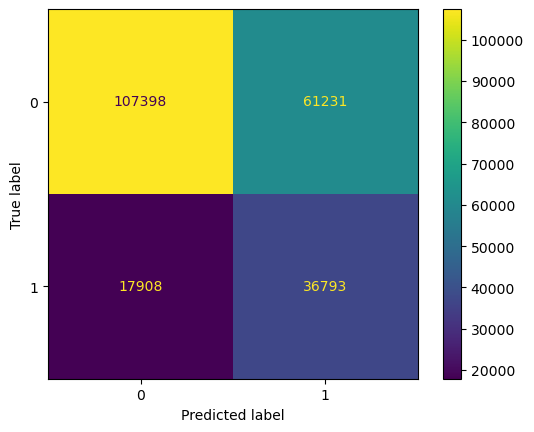

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, val_pred)

### Logistic Regression Baseline Summary

**Goal:** Build an interpretable baseline model for loan default prediction using Logistic Regression with `class_weight='balanced'`.

---

#### Feature Reduction

Redundant features were removed in one pass — a correlation check, then a VIF check — instead of doing it in multiple rounds.

**Dropped due to high correlation (>0.85):**
- `int_rate` (correlated with `sub_grade`)
- `tot_cur_bal`, `tot_hi_cred_lim` (correlated with `avg_cur_bal`)
- `total_bal_il` (correlated with `total_il_high_credit_limit`)
- `has_rcnt_il` (correlated with `has_installment_accts`)
- `pti_ratio` (correlated with `loan_to_income`)

**Dropped for other reasons (LR only):**
- 5 sentinel columns (`mths_since_*`) — the value `999` means "never happened," which distorts a linear model. Kept the matching flag columns instead.
- 14 tradeline columns — missing for most loans before 2015.
- `issue_year` — risks the model learning the training period instead of real risk signal.
- `delinq_amnt` — no variation in the data.

**VIF check:** Dropped `['num_rev_accts','pub_rec']

---

#### Final Model

- **Val ROC-AUC:** 0.7151
- **Val KS:** 0.3100
- **Val Brier:** 0.2222
- **Train/Val AUC gap:** 0.0106 (good fit)

**Conclusion:** Removing redundant features didn't hurt performance — AUC stayed the same as earlier, less-clean versions of this model. This is the final Logistic Regression baseline, used to benchmark Random Forest, XGBoost, and LightGBM.

## Phase 1 — Tree-Based Models(With Tradeline Columns)

In [33]:
print(f"X_train shape: {X_train.shape}")    
print(f"X_val shape:   {X_val.shape}")      
print(f"X_test shape:  {X_test.shape}")     
print(f"NaNs:          {X_train.isnull().sum().sum()}")  

X_train shape: (623267, 150)
X_val shape:   (223330, 150)
X_test shape:  (180970, 150)
NaNs:          8528337


In [34]:
tree_drop_flags = [ 
    'ever_delinquent', 
    'has_public_record', 
    'has_bc_delinquency', 
    'has_major_derog',          
    'has_revol_delinq', 
] 

In [35]:
# Drop tradeline cols + zero variance col
drop_cols = tradeline_data_keep_nan + tree_drop_flags + ['delinq_amnt'] + ['issue_year']

X_train_rf = X_train.drop(columns=drop_cols, errors='ignore')
X_val_rf   = X_val.drop(columns=drop_cols,   errors='ignore')
X_test_rf  = X_test.drop(columns=drop_cols,  errors='ignore')

# Verify
print(f"X_train_rf shape: {X_train_rf.shape}")   
print(f"X_val_rf shape:   {X_val_rf.shape}")     
print(f"X_test_rf shape:  {X_test_rf.shape}")    
print(f"NaNs:          {X_train_rf.isnull().sum().sum()}")  

X_train_rf shape: (623267, 129)
X_val_rf shape:   (223330, 129)
X_test_rf shape:  (180970, 129)
NaNs:          0


### **Phase 1A — Random Forest**

In [36]:
#Train
from sklearn.ensemble import RandomForestClassifier
import time

# =========================
#  Model Definition
# =========================
rf = RandomForestClassifier(
    n_estimators=200,        
    max_depth=8,          
    min_samples_leaf=50,     
    max_features='sqrt',      
    class_weight='balanced', 
    n_jobs = 4,
    random_state=42,
    verbose=1
)

start = time.time()

# =========================
#  Training
# =========================
rf.fit(X_train_rf, y_train)

print(f"Training time: {time.time() - start:.1f}s")


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   30.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  2.1min


Training time: 135.1s


[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:  2.2min finished


In [37]:
train_results, val_results = evaluate_train_val(
    
    rf, X_train_rf, y_train, X_val_rf, y_val, model_name = 'Random Forest Classifier'
    
)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    5.3s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    5.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    1.9s finished


=== Random Forest Classifier - Train ===
ROC-AUC:      0.7263
PR-AUC:       0.3806
Gini:         0.4526
KS statistic: 0.3275
Brier score:  0.2145
Top 10% (D10) default rate: 46.20%  (lift: 2.48x)

=== Random Forest Classifier - Val ===
ROC-AUC:      0.7109
PR-AUC:       0.4349
Gini:         0.4219
KS statistic: 0.3034
Brier score:  0.2115
Top 10% (D10) default rate: 52.52%  (lift: 2.14x)

Train/Val ROC-AUC gap: 0.0154  (Good fit)


### Random Forest 

**Config:** `n_estimators=200`, `class_weight='balanced'`, `max_features='sqrt'`, `min_samples_leaf=50`, `n_jobs=4`
**Feature set:** 137 (152 total − 14 tradeline columns − `delinq_amnt`)

| max_depth | Train AUC | Val AUC | Val KS | Train/Val Gap |
|---|---|---|---|---|
| None (unlimited) | 0.8182 | 0.7175 | 0.3130 | 0.1007 (overfitting) |
| 8 | 0.7263 | 0.7109 | 0.3034 | 0.0154 (underfitting) |
| 12 | 0.7600 | 0.7155 | 0.3096 | 0.0445 |

**Findings:**
- Unlimited depth overfits — train AUC is far above val, but val doesn't improve over the baseline
- `depth=8` fixes the gap but underperforms — too shallow to capture signal, worse than LR on val
- `depth=12` improves over `depth=8`, but still doesn't beat LR on val
- Across all three depths, val AUC stays close to 0.71–0.72 — RF isn't meaningfully outperforming Logistic Regression on this feature set

---

**Comparison to LR baseline:**

| Model | Val AUC | Val KS | Train/Val Gap |
|---|---|---|---|
| LR2 (VIF-cleaned) | 0.7151 | 0.3106 | 0.0154 |
| RF (best: depth=None) | 0.7175 | 0.3130 | 0.1007 |

**Conclusion:** Random Forest does not meaningfully outperform the Logistic Regression baseline at any depth tested. This suggests the relationship between features and default risk is close to linear — top predictors (sub_grade/int_rate, FICO, DTI) likely already have a near-monotonic relationship with risk, which is exactly the setting where trees don't have much of an edge over a well-regularized linear model.

**Decision:** Not pursuing further RF tuning. Moving to XGBoost.


### **Phase 1B — XGBoost**

In [38]:
# Drop issue_year + zero variance col
drop_cols =  tree_drop_flags + ['delinq_amnt'] + ['issue_year']

X_train_xgb = X_train.drop(columns=drop_cols, errors='ignore')
X_val_xgb   = X_val.drop(columns=drop_cols,   errors='ignore')
X_test_xgb  = X_test.drop(columns=drop_cols,  errors='ignore')

# Verify
print(f"X_train_xgb shape: {X_train_xgb.shape}")   
print(f"X_val_xgb shape:   {X_val_xgb.shape}")     
print(f"X_test_xgb shape:  {X_test_xgb.shape}")    
print(f"NaNs:          {X_train_xgb.isnull().sum().sum()}")

X_train_xgb shape: (623267, 143)
X_val_xgb shape:   (223330, 143)
X_test_xgb shape:  (180970, 143)
NaNs:          8528337


In [39]:
from xgboost import XGBClassifier
import time

# Class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight: {scale_pos_weight:.2f}\n")

# =========================
#  Model Definition
# =========================
xgb = XGBClassifier(
    n_estimators=1500,
    max_depth=4,               
    learning_rate=0.05,        # slow learning — better generalization
    subsample=0.8,             # 80% rows per tree — reduces overfitting
    colsample_bytree=0.8,      # 80% features per tree — reduces overfitting
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    tree_method='hist',        # faster, more memory-efficient on this data size
    eval_metric='auc',
    early_stopping_rounds=50,  # stop if no improvement for 50 rounds
    n_jobs = 4,
    random_state=42
)

start = time.time()

# =========================
#  Training
# =========================
xgb.fit(
    X_train_xgb, y_train, 
    eval_set = [(X_val_xgb, y_val)],   # monitor val AUC during training
    verbose = 100                  # print every 100 rounds
)              

print(f"Training time: {time.time() - start:.1f}s")

print(f"Best iteration: {xgb.best_iteration}")

print(f"Best val AUC during training: {xgb.best_score:.4f}")

scale_pos_weight: 4.37

[0]	validation_0-auc:0.68926
[100]	validation_0-auc:0.71261
[200]	validation_0-auc:0.71761
[300]	validation_0-auc:0.71993
[400]	validation_0-auc:0.72145
[500]	validation_0-auc:0.72254
[600]	validation_0-auc:0.72301
[700]	validation_0-auc:0.72341
[800]	validation_0-auc:0.72371
[843]	validation_0-auc:0.72370
Training time: 346.1s
Best iteration: 794
Best val AUC during training: 0.7237


In [40]:
train_results, val_results = evaluate_train_val(
    
    xgb, X_train_xgb, y_train, X_val_xgb, y_val, model_name = 'XGBoost'
    
)

=== XGBoost - Train ===
ROC-AUC:      0.7496
PR-AUC:       0.4146
Gini:         0.4992
KS statistic: 0.3639
Brier score:  0.2043
Top 10% (D10) default rate: 49.68%  (lift: 2.67x)

=== XGBoost - Val ===
ROC-AUC:      0.7237
PR-AUC:       0.4545
Gini:         0.4475
KS statistic: 0.3240
Brier score:  0.2162
Top 10% (D10) default rate: 54.83%  (lift: 2.24x)

Train/Val ROC-AUC gap: 0.0259  (Good fit)


In [41]:
print(f"Mean predicted probability (val): {xgb.predict_proba(X_val_xgb)[:,1].mean():.4f}")
print(f"Actual default rate (val): {y_val.mean():.4f}")

Mean predicted probability (val): 0.4659
Actual default rate (val): 0.2449


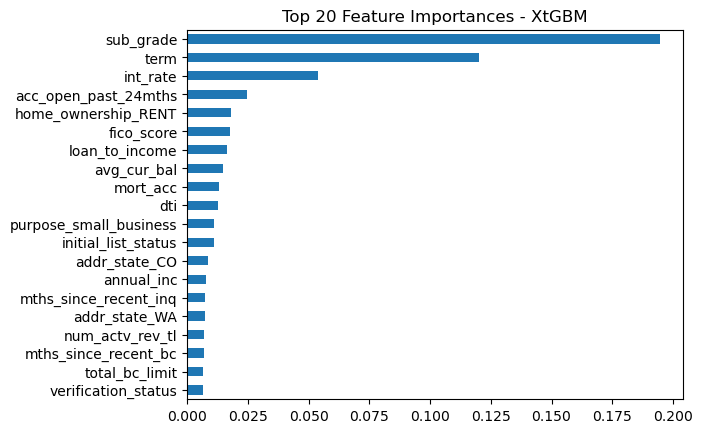

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(xgb.feature_importances_, index=X_train_xgb.columns)
importances.nlargest(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances - XtGBM')
plt.show()

In [43]:
importances.nlargest(20)

sub_grade                 0.194485
term                      0.120237
int_rate                  0.053855
acc_open_past_24mths      0.024526
home_ownership_RENT       0.017859
fico_score                0.017745
loan_to_income            0.016238
avg_cur_bal               0.014866
mort_acc                  0.012922
dti                       0.012770
purpose_small_business    0.010974
initial_list_status       0.010947
addr_state_CO             0.008408
annual_inc                0.007644
mths_since_recent_inq     0.007522
addr_state_WA             0.007292
num_actv_rev_tl           0.006990
mths_since_recent_bc      0.006763
total_bc_limit            0.006698
verification_status       0.006493
dtype: float32

In [44]:
!pip install lightgbm

### **Phase 1C — LightGBM**

In [45]:
# Drop tradeline cols + zero variance col
drop_cols = tree_drop_flags + ['delinq_amnt'] + ['issue_year']

X_train_lgbm = X_train.drop(columns=drop_cols, errors='ignore')
X_val_lgbm   = X_val.drop(columns=drop_cols,   errors='ignore')
X_test_lgbm  = X_test.drop(columns=drop_cols,  errors='ignore')

# Verify
print(f"X_train_lgbm shape: {X_train_lgbm.shape}")   
print(f"X_val_lgbm shape:   {X_val_lgbm.shape}")     
print(f"X_test_lgbm shape:  {X_test_lgbm.shape}")    
print(f"NaNs:          {X_train_lgbm.isnull().sum().sum()}")

X_train_lgbm shape: (623267, 143)
X_val_lgbm shape:   (223330, 143)
X_test_lgbm shape:  (180970, 143)
NaNs:          8528337


In [46]:
import lightgbm as lgb 
from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping, log_evaluation

# =========================
#  Model Definition
# =========================

lgbm = lgb.LGBMClassifier(
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,         # replaces scale_pos_weight
    eval_metric='auc',
    n_jobs=4,
    random_state=42,
    verbose=-1
)
# =========================
#  Training
# =========================
start = time.time()
lgbm.fit(
    X_train_lgbm, y_train,
    eval_set=[(X_val_lgbm, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(100)
    ]
)

print(f"Training time: {time.time() - start:.1f}s")

print(f"Converged: {lgbm.n_iter_}")

print(f"Iterations: {lgbm.n_iter_}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.712974	valid_0's binary_logloss: 0.606815
[200]	valid_0's auc: 0.717369	valid_0's binary_logloss: 0.618236
[300]	valid_0's auc: 0.719613	valid_0's binary_logloss: 0.619244
[400]	valid_0's auc: 0.720979	valid_0's binary_logloss: 0.621209
[500]	valid_0's auc: 0.721899	valid_0's binary_logloss: 0.620871
[600]	valid_0's auc: 0.722593	valid_0's binary_logloss: 0.620804
[700]	valid_0's auc: 0.722713	valid_0's binary_logloss: 0.620292
[800]	valid_0's auc: 0.722678	valid_0's binary_logloss: 0.619463
[900]	valid_0's auc: 0.722668	valid_0's binary_logloss: 0.61912
Early stopping, best iteration is:
[843]	valid_0's auc: 0.72278	valid_0's binary_logloss: 0.61919
Evaluated only: auc
Training time: 69.7s
Converged: 843
Iterations: 843


In [47]:
train_results, val_results = evaluate_train_val(
    
    lgbm, X_train_lgbm, y_train, X_val_lgbm, y_val, model_name = 'LightGBM'
    
)

=== LightGBM - Train ===
ROC-AUC:      0.7498
PR-AUC:       0.4157
Gini:         0.4996
KS statistic: 0.3650
Brier score:  0.2043
Top 10% (D10) default rate: 49.67%  (lift: 2.67x)

=== LightGBM - Val ===
ROC-AUC:      0.7228
PR-AUC:       0.4534
Gini:         0.4456
KS statistic: 0.3224
Brier score:  0.2160
Top 10% (D10) default rate: 54.89%  (lift: 2.24x)

Train/Val ROC-AUC gap: 0.0270  (Good fit)


In [48]:
print(f"Mean predicted probability (val): {lgbm.predict_proba(X_val_lgbm)[:,1].mean():.4f}")
print(f"Actual default rate (val): {y_val.mean():.4f}")

Mean predicted probability (val): 0.4650
Actual default rate (val): 0.2449


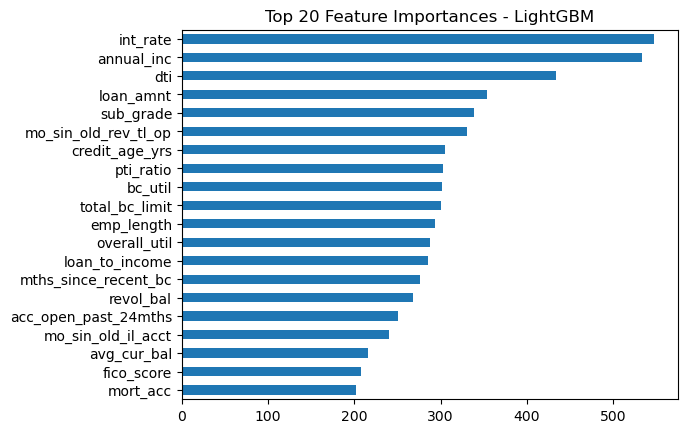

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(lgbm.feature_importances_, index=X_train_lgbm.columns)
importances.nlargest(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances - LightGBM')
plt.show()

In [50]:
importances.nlargest(20)

int_rate                548
annual_inc              534
dti                     434
loan_amnt               354
sub_grade               339
mo_sin_old_rev_tl_op    331
credit_age_yrs          305
pti_ratio               303
bc_util                 302
total_bc_limit          300
emp_length              294
overall_util            288
loan_to_income          285
mths_since_recent_bc    276
revol_bal               268
acc_open_past_24mths    251
mo_sin_old_il_acct      240
avg_cur_bal             216
fico_score              208
mort_acc                202
dtype: int32

---

### Model Comparison — With Tradeline Data

| Model | Features | Val ROC-AUC | Val KS | Val Brier | Train/Val Gap |
|---|---|---|---|---|---|
| Logistic Regression (LR2) | 122 | 0.7151 | 0.3106 | 0.2222 | 0.0105 (good fit) |
| Random Forest | 129 | 0.7109 | 0.3034 | 0.2115| 0.0154 (good fit) |
| XGBoost | 143 | 0.7237 |  0.3240 | 0.2162 | 0.0259  (good fit) |
| LightGBM | 143 | 0.7228 | 0.3224 | 0.2163 | 0.0270  (good fit) |

**Findings:**
- XGBoost gives the best Val ROC-AUC and KS among all models, followed closely by LightGBM
- Logistic Regression remains competitive despite being a linear model, suggesting the underlying relationship between features and default risk is largely linear

**Conclusion:** With tradeline features included, XGBoost is the top performer, offering the best balance of predictive power and generalization.

## Phase 2 — Tree-Based Models(With Tradeline Columns)

### **Phase 2A — XGB**

In [51]:
# Drop issue_year + zero variance col
drop_cols =  tradeline_data_keep_nan + tree_drop_flags + ['delinq_amnt'] + ['issue_year']

X_train_xgb_2 = X_train.drop(columns=drop_cols, errors='ignore')
X_val_xgb_2   = X_val.drop(columns=drop_cols,   errors='ignore')
X_test_xgb_2  = X_test.drop(columns=drop_cols,  errors='ignore')

# Verify
print(f"X_train_xgb_2 shape: {X_train_xgb_2.shape}")   
print(f"X_val_xgb_2 shape:   {X_val_xgb_2.shape}")     
print(f"X_test_xgb_2 shape:  {X_test_xgb_2.shape}")    
print(f"NaNs:          {X_train_xgb_2.isnull().sum().sum()}")

X_train_xgb_2 shape: (623267, 129)
X_val_xgb_2 shape:   (223330, 129)
X_test_xgb_2 shape:  (180970, 129)
NaNs:          0


In [52]:
from xgboost import XGBClassifier
import time

# Class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight: {scale_pos_weight:.2f}\n")

# =========================
#  Model Definition
# =========================
xgb_2 = XGBClassifier(
    n_estimators=1500,
    max_depth=4,               #  starting point
    learning_rate=0.05,        # slow learning — better generalization
    subsample=0.8,             # 80% rows per tree — reduces overfitting
    colsample_bytree=0.8,      # 80% features per tree — reduces overfitting
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    tree_method='hist',        # faster, more memory-efficient on this data size
    eval_metric='auc',
    early_stopping_rounds=50,  # stop if no improvement for 50 rounds
    n_jobs = 4,
    random_state=42
)

start = time.time()

# =========================
#  Training
# =========================
xgb_2.fit(
    X_train_xgb_2, y_train, 
    eval_set = [(X_val_xgb_2, y_val)],   # monitor val AUC during training
    verbose = 100                  # print every 100 rounds
)              

print(f"Training time: {time.time() - start:.1f}s")

print(f"Best iteration: {xgb_2.best_iteration}")

print(f"Best val AUC during training: {xgb_2.best_score:.4f}")

scale_pos_weight: 4.37

[0]	validation_0-auc:0.68857
[100]	validation_0-auc:0.71265
[200]	validation_0-auc:0.71712
[300]	validation_0-auc:0.71944
[400]	validation_0-auc:0.72107
[500]	validation_0-auc:0.72248
[600]	validation_0-auc:0.72339
[700]	validation_0-auc:0.72412
[800]	validation_0-auc:0.72459
[900]	validation_0-auc:0.72489
[1000]	validation_0-auc:0.72510
[1100]	validation_0-auc:0.72529
[1196]	validation_0-auc:0.72544
Training time: 405.2s
Best iteration: 1147
Best val AUC during training: 0.7255


In [53]:
train_results, val_results = evaluate_train_val(
    
    xgb_2, X_train_xgb_2, y_train, X_val_xgb_2, y_val, model_name = 'XGBoost'
    
)

=== XGBoost - Train ===
ROC-AUC:      0.7559
PR-AUC:       0.4230
Gini:         0.5117
KS statistic: 0.3740
Brier score:  0.2022
Top 10% (D10) default rate: 50.37%  (lift: 2.70x)

=== XGBoost - Val ===
ROC-AUC:      0.7255
PR-AUC:       0.4563
Gini:         0.4509
KS statistic: 0.3270
Brier score:  0.2143
Top 10% (D10) default rate: 54.94%  (lift: 2.24x)

Train/Val ROC-AUC gap: 0.0304  (Check for overfitting)


### **Phase 2B — LightGBM**

In [54]:
# Drop issue_year + zero variance col
drop_cols =  tradeline_data_keep_nan + tree_drop_flags + ['delinq_amnt'] + ['issue_year']

X_train_lgbm_2 = X_train.drop(columns=drop_cols, errors='ignore')
X_val_lgbm_2   = X_val.drop(columns=drop_cols,   errors='ignore')
X_test_lgbm_2  = X_test.drop(columns=drop_cols,  errors='ignore')

# Verify
print(f"X_train_lgbm_2 shape: {X_train_lgbm_2.shape}")   
print(f"X_val_lgbm_2 shape:   {X_val_lgbm_2.shape}")     
print(f"X_test_lgbm_2 shape:  {X_test_lgbm_2.shape}")    
print(f"NaNs:          {X_train_lgbm_2.isnull().sum().sum()}")

X_train_lgbm_2 shape: (623267, 129)
X_val_lgbm_2 shape:   (223330, 129)
X_test_lgbm_2 shape:  (180970, 129)
NaNs:          0


In [55]:
import lightgbm as lgb 
from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping, log_evaluation

# =========================
#  Model Definition
# =========================

lgbm_2 = lgb.LGBMClassifier(
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,         
    eval_metric='auc',
    n_jobs=4,
    random_state=42,
    verbose=-1
)
# =========================
#  Training
# =========================
start = time.time()
lgbm_2.fit(
    X_train_lgbm_2, y_train,
    eval_set=[(X_val_lgbm_2, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(100)
    ]
)

print(f"Training time: {time.time() - start:.1f}s")

print(f"Converged: {lgbm_2.n_iter_}")

print(f"Iterations: {lgbm_2.n_iter_}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.713001	valid_0's binary_logloss: 0.612888
[200]	valid_0's auc: 0.716718	valid_0's binary_logloss: 0.620127
[300]	valid_0's auc: 0.718738	valid_0's binary_logloss: 0.622437
[400]	valid_0's auc: 0.71991	valid_0's binary_logloss: 0.622634
[500]	valid_0's auc: 0.720875	valid_0's binary_logloss: 0.621413
[600]	valid_0's auc: 0.721626	valid_0's binary_logloss: 0.620522
[700]	valid_0's auc: 0.722191	valid_0's binary_logloss: 0.620415
[800]	valid_0's auc: 0.722521	valid_0's binary_logloss: 0.619109
[900]	valid_0's auc: 0.722629	valid_0's binary_logloss: 0.618261
[1000]	valid_0's auc: 0.722799	valid_0's binary_logloss: 0.617209
[1100]	valid_0's auc: 0.723027	valid_0's binary_logloss: 0.61637
[1200]	valid_0's auc: 0.723036	valid_0's binary_logloss: 0.615567
[1300]	valid_0's auc: 0.723215	valid_0's binary_logloss: 0.615686
[1400]	valid_0's auc: 0.723339	valid_0's binary_logloss: 0.615428
[1500]	valid_0's auc: 0.7

In [56]:
train_results, val_results = evaluate_train_val(
    
    lgbm_2, X_train_lgbm_2, y_train, X_val_lgbm_2, y_val, model_name = 'LightGBM 2'
    
)

=== LightGBM 2 - Train ===
ROC-AUC:      0.7581
PR-AUC:       0.4262
Gini:         0.5162
KS statistic: 0.3775
Brier score:  0.2033
Top 10% (D10) default rate: 50.84%  (lift: 2.73x)

=== LightGBM 2 - Val ===
ROC-AUC:      0.7234
PR-AUC:       0.4538
Gini:         0.4467
KS statistic: 0.3223
Brier score:  0.2142
Top 10% (D10) default rate: 55.00%  (lift: 2.25x)

Train/Val ROC-AUC gap: 0.0347  (Check for overfitting)


### Model Comparison — Without Tradeline Data

| Model | Features | Val ROC-AUC | Val KS | Val Brier | Train/Val Gap |
|---|---|---|---|---|---|
| XGBoost | 131 | 0.7255 | 0.3270 | 0.2143 | 0.0304 (mild overfit) |
| LightGBM | 131 | 0.7234 | 0.3223 | 0.2142 | 0.0337 (mild overfit) |

**Findings:**
- Both XGBoost and LightGBM improve slightly on Val AUC when tradeline features are removed, at the cost of a wider train/val gap.
- XGBoost remains the stronger of the two, though the difference is small (~0.002 Val AUC).
- Random Forest was not retrained without tradeline data in this experiment — only tested with tradeline features included.

**Conclusion:** At the validation stage, removing tradeline features gave XGBoost a marginally higher AUC, but a wider train/val gap. This validation-stage result was not sufficient on its own to decide the final feature set, so only the with-tradeline versions of XGBoost were carried forward to test-set evaluation (2017–2018).

**Outcome (see Final Model Selection):** On the held-out test set, XGBoost with tradeline features scored higher on every predictive metric (AUC, KS, Brier) than the without-tradeline version, and showed a tighter train/val gap. XGBoost with tradeline was selected as the final production model — see the Final Model Selection section for the full test comparison and reasoning.

---
### **Overall Summary**
- Built a strong Logistic Regression baseline to serve as the main reference model for comparison.
- Handled sentinel-based tradeline features carefully, since they were not suitable for linear modeling in their raw form.
- Reduced multicollinearity through correlation and VIF-based feature removal to improve interpretability and stability.
- Random Forest did not produce a meaningful improvement over the baseline, and deeper trees showed overfitting.
- XGBoost and LightGBM captured non-linear patterns better than Logistic Regression, with tree-based models giving the best overall validation performance.
- Tradeline features added useful signal for tree models, confirmed on the held-out test set, though they also introduced some overfitting risk.
- A separate experiment training only on 2016 data (with tradeline features fully populated) matched the main model's test AUC despite using half the data, but was not selected as final — its pipeline was fit on a single year, making it more fragile to future drift than a model trained across 2007–2015's broader economic range.
- The model's predicted probabilities are not fully calibrated — its risk *ranking* is reliable, but raw predicted percentages run higher than true default rates. A calibrated version (e.g. via `CalibratedClassifierCV`) would be needed if actual probability values, not just relative risk ranking, are required.
- **Final model: XGBoost, trained on 2007–2015 with tradeline features included** — chosen for its combination of strong test performance and a preprocessing pipeline built on a wider, more economically diverse training window. Logistic Regression remains a documented, interpretable benchmark, not a deployment candidate.
---
### **Limitations**
- The dataset showed time drift, which reduced model generalization on future-like data.
- Some engineered features, such as grouped employment-title categories, introduced noise instead of contributing strong predictive signal and were not retained.
- Several feature engineering changes resulted in only marginal improvement and were not consistently stable across validation.
- Tree-based models performed better than the baseline, but some configurations still showed mild overfitting.
- Model performance appeared to be constrained more by

In [57]:
import joblib
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODEL_DIR = os.path.join(project_root, 'src', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Experiment 1 candidates

joblib.dump(xgb, os.path.join(MODEL_DIR, 'xgb_with_tradeline.pkl'))
joblib.dump(list(X_train_xgb.columns), os.path.join(MODEL_DIR, 'xgb_with_tradeline_features.pkl'))

joblib.dump(xgb_2, os.path.join(MODEL_DIR, 'xgb_no_tradeline.pkl'))
joblib.dump(list(X_train_xgb_2.columns), os.path.join(MODEL_DIR, 'xgb_no_tradeline_features.pkl'))

joblib.dump(lgbm, os.path.join(MODEL_DIR, 'lgbm_with_tradeline.pkl'))
joblib.dump(list(X_train_lgbm.columns), os.path.join(MODEL_DIR, 'lgbm_with_tradeline_features.pkl'))

print("All models saved to:", MODEL_DIR)
print(os.listdir(MODEL_DIR))

All models saved to: C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML\src\models
['.ipynb_checkpoints', 'lgbm_with_tradeline.pkl', 'lgbm_with_tradeline_features.pkl', 'lr2_features.pkl', 'lr2_final.pkl', 'xgb_modern.pkl', 'xgb_modern_features.pkl', 'xgb_no_tradeline.pkl', 'xgb_no_tradeline_features.pkl', 'xgb_with_tradeline.pkl', 'xgb_with_tradeline_features.pkl']


In [58]:
print(f"Exp1 addr_state dummies: {len([c for c in X_train_xgb.columns if c.startswith('addr_state_')])}")
print(f"Exp1 purpose dummies: {len([c for c in X_train_xgb.columns if c.startswith('purpose_')])}")
print(f"Exp1 home_ownership dummies: {len([c for c in X_train_xgb.columns if c.startswith('home_ownership_')])}")

Exp1 addr_state dummies: 47
Exp1 purpose dummies: 13
Exp1 home_ownership dummies: 3
